<h1 style="color: darkgray;font-family:san=serif;text-align:left;font-weight:bold;font-size:30px">Import Libraries</h1>

In [1]:
import sys
sys.path.insert(0, r"C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE")

from lib_file import lib_path
print(lib_path)

C:\Users\manpu\Downloads\Ambulence_call_volume_Shylender_Rao_Dissertation_final\Toshylandhar\Shylendar_Ambulence_Call_Volume_FE


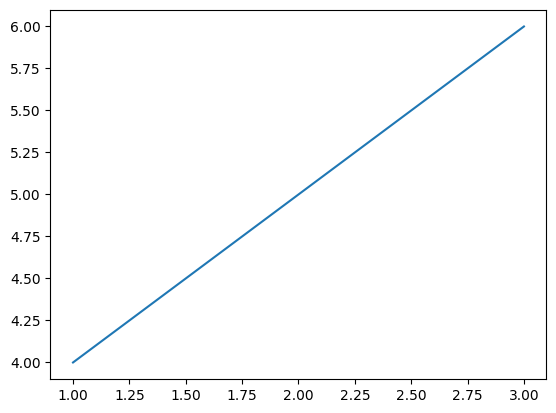

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from lib_file import lib_path
import os
import numpy as np
import matplotlib.pyplot as plt
plt.plot([1,2,3],[4,5,6])
plt.show()
import seaborn as sns

<h1 style="color: darkgray;font-family:san=serif;text-align:left;font-weight:bold;font-size:30px">Data Loading</h1>

In [3]:
data_dir = "ambulance_data"

In [4]:
dfs = {}

# Loop through all CSV files in the folder
for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(data_dir, file)
        try:
            df = pd.read_csv(file_path)
            dfs[file] = df
            print(f"\n=== {file} ===")
            print(df.columns.tolist())
        except Exception as e:
            print(f"Error loading {file}: {e}")


=== 2013-2015-dfb-ambulance.csv ===
['Date', 'Station Area', 'Clinical Status', 'TOC', 'ORD', 'MOB', 'IA', 'LS', 'AH', 'MAV', 'CD']

=== 2023-open-data-dfb-ambulance.csv ===
['ID', 'Date', 'Station Name', 'criticality', 'TOC', 'ORD', 'MOB', 'IA', 'LS', 'AH', 'MAV', 'CD']

=== da-opendata-2016-to-2017-with-stn-area.csv ===
['ID', 'Date', 'Station Name', 'criticality', 'TOC', 'ORD', 'MOB', 'IA', 'LS', 'AH', 'MAV', 'CD']

=== da-opendata-2018-to-2019-with-stn-area.csv ===
['ID', 'Date', 'Station Name', 'criticality', 'TOC', 'ORD', 'MOB', 'IA', 'LS', 'AH', 'MAV', 'CD']

=== da-opendata-2020-to-2022-with-stn-area.csv ===
['ID', 'Date', 'Station Name', 'criticality', 'TOC', 'ORD', 'MOB', 'IA', 'LS', 'AH', 'MAV']




### **Column Mapping Table**

| Dataset file                                   | Original Columns                                                                                | Notes                                                                                                 |
| ---------------------------------------------- | ----------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| **2013-2015-dfb-ambulance.csv**                | `Date`, `Station Area`, `Clinical Status`, `TOC`, `ORD`, `MOB`, `IA`, `LS`, `AH`, `MAV`, `CD`   | Has `Station Area` instead of `Station Name`. Has `Clinical Status`. All operational columns present. |
| **2023-open-data-dfb-ambulance.csv**           | `ID`, `Date`, `Station Name`, `criticality`, `TOC`, `ORD`, `MOB`, `IA`, `LS`, `AH`, `MAV`, `CD` | Has `Station Name` instead of `Station Area`. Has `criticality`. All operational columns present.     |
| **da-opendata-2016-to-2017-with-stn-area.csv** | Same as 2023 dataset                                                                            | Same structure, different years.                                                                      |
| **da-opendata-2018-to-2019-with-stn-area.csv** | Same as 2023 dataset                                                                            | Same structure, different years.                                                                      |
| **da-opendata-2020-to-2022-with-stn-area.csv** | Same as 2023 dataset but **missing `CD` column**                                                | Missing one operational column.                                                                       |

---

### **Missing Columns**

From your comparison:

* **`Station Name` vs `Station Area`** → These are the same thing logically (station identifier) but have different names.
* **`Clinical Status`** → Present only in 2013–2015 data, not used in prediction.
* **`criticality`** → Present in later datasets, but not in early ones.
* **`ID`** → Present in later datasets, not in early ones, and irrelevant for prediction.
* **`CD`** → Missing in `da-opendata-2020-to-2022-with-stn-area.csv`.

---



***STANDARDIZE COLUMNS***

In [5]:
def standardize_columns(df):
    # Clean column names
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    
    # Unify station column
    if "station_name" in df.columns:
        df.rename(columns={"station_name": "station_id"}, inplace=True)
    elif "station_area" in df.columns:
        df.rename(columns={"station_area": "station_id"}, inplace=True)
    
    # Unify criticality column
    if "criticality" in df.columns:
        pass  # Already correct
    elif "clinical_status" in df.columns:
        df.rename(columns={"clinical_status": "criticality"}, inplace=True)
    
    # Map criticality values to a standard set
    crit_map = {
        "Alpha": "A", "Bravo": "B", "Charlie": "C", "Delta": "D",
        "alpha": "A", "bravo": "B", "charlie": "C", "delta": "D",
        "Omega":"O", "BRAVO": "B",
        "A": "A", "B": "B", "C": "C", "D": "D"
    }
    if "criticality" in df.columns:
        df['criticality'] = df['criticality'].map(crit_map).fillna(df['criticality'])
    
    # Keep only relevant columns
    keep_cols = {"station_id", "date", "criticality", "toc", "ord", "mob", "ia", "ls", "ah", "mav", "cd"}
    df = df[[col for col in df.columns if col in keep_cols]]
    
    return df


In [6]:
# Apply to all datasets
for file in dfs:
    dfs[file] = standardize_columns(dfs[file])

# COMBINE DATA
df = pd.concat(dfs.values(), ignore_index=True)

***Preliminary Analysis***

In [7]:
df['station_id'].value_counts()

station_id
Tallaght Fire Station          104381
Tara Street Fire Station        79775
Kilbarrack Fire Station         75742
Phibsborough Fire Station       66881
Dolphins Barn Fire Station      64370
Finglas Fire Station            62347
Blanchardstown Fire Station     39381
Rathfarnharm Fire Station       38157
Tallaght                        34773
North Strand Fire Station       31255
Tara St                         30765
Swords Fire Station             26596
Donnybrook Fire Station         25415
Kilbarrack                      24895
Phibsborough                    23824
Dolphins Barn                   23185
Finglas                         20953
Blanchardstown                  14753
Rathfarnham                     12647
North Strand                    10898
Balbriggan Fire Station         10364
Donnybrook                      10144
Skerries Fire Station            8526
Swords                           8226
Balbriggan                       2906
Skerries                         2338
D

***standardize_station***

In [8]:
station_mapping = {
    "Tallaght": "Tallaght Fire Station",
    "Tara St": "Tara Street Fire Station",
    "Kilbarrack": "Kilbarrack Fire Station",
    "Phibsborough": "Phibsborough Fire Station",
    "Dolphins Barn": "Dolphins Barn Fire Station",
    "Finglas": "Finglas Fire Station",
    "Blanchardstown": "Blanchardstown Fire Station",
    "Rathfarnham": "Rathfarnharm Fire Station",   # Note spelling correction
    "North Strand": "North Strand Fire Station",
    "Donnybrook": "Donnybrook Fire Station",
    "Swords": "Swords Fire Station",
    "Balbriggan": "Balbriggan Fire Station",
    "Skerries": "Skerries Fire Station",
    "Dun Laoghaire": "Dun Laoghaire Fire Station",
}

def standardize_station(station_id: str) -> str:
    """Standardize station_id names to avoid duplicates."""
    if pd.isna(station_id) or station_id == "Null":
        return "Unknown Station"  # handle missing
    return station_mapping.get(station_id, station_id)

# Apply to dataframe
df['station_id'] = df['station_id'].apply(standardize_station)

# Check result
print(df['station_id'].value_counts())


station_id
Tallaght Fire Station          139154
Tara Street Fire Station       110540
Kilbarrack Fire Station        100637
Phibsborough Fire Station       90705
Dolphins Barn Fire Station      87555
Finglas Fire Station            83300
Blanchardstown Fire Station     54134
Rathfarnharm Fire Station       50804
North Strand Fire Station       42153
Donnybrook Fire Station         35559
Swords Fire Station             34822
Balbriggan Fire Station         13270
Skerries Fire Station           10864
Dun Laoghaire Fire Station       2635
MH14                                9
Unknown Station                     9
MH17                                2
Dunshaughlin                        1
Name: count, dtype: int64


In [9]:
df.head()

,date,station_id,criticality,toc,ord,mob,ia,ls,ah,mav,cd
0,01/01/2013,Tallaght Fire Station,Non ProQa Class,00:02:09,00:04:14,00:04:58,00:10:16,NaN,NaN,00:27:47,00:29:24
1,01/01/2013,Tara Street Fire Station,B,00:02:41,00:14:41,00:15:04,00:18:10,NaN,NaN,00:20:52,00:22:47
2,01/01/2013,Finglas Fire Station,D,00:13:52,00:16:26,00:16:51,00:25:06,00:29:36,00:37:35,00:41:49,00:47:15
3,01/01/2013,Tara Street Fire Station,B,00:06:58,00:22:33,00:22:59,00:34:48,NaN,NaN,00:43:21,00:44:18
4,01/01/2013,Tara Street Fire Station,A,00:14:56,00:23:25,00:23:35,00:27:25,00:39:19,NaN,01:05:37,01:12:15


In [10]:
df['criticality'].value_counts()

criticality
D                  389838
A                  152221
C                  138257
B                  119250
O                   30818
E                   19731
Non ProQa Class      4472
Echo                  865
Not Classed           481
Null                  220
Name: count, dtype: int64

In [11]:
df.shape

(856153, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856153 entries, 0 to 856152
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   date         856153 non-null  object
 1   station_id   856153 non-null  object
 2   criticality  856153 non-null  object
 3   toc          856153 non-null  object
 4   ord          856153 non-null  object
 5   mob          837889 non-null  object
 6   ia           714459 non-null  object
 7   ls           529218 non-null  object
 8   ah           558188 non-null  object
 9   mav          778285 non-null  object
 10  cd           619515 non-null  object
dtypes: object(11)
memory usage: 71.9+ MB



| Column      |  Explanation                                                         |
| ----------- | -------------------------------------------------------------------- |
| id          | Unique identifier for each incident record.                          |
| date        | Date and time of the incident.                                       |
| station\_id | Name/ID of the fire or ambulance station handling the incident.      |
| criticality | Severity classification of the call (e.g., high, medium, low).       |
| toc         | Time of Call — when the emergency call was received.                 |
| ord         | Order Time — when the dispatch order was issued.                     |
| mob         | Mobilization Time — when the crew became mobile/en route.            |
| ia          | Incident Arrival Time — when the crew arrived at the scene.          |
| ls          | Left Scene Time — when the crew departed the scene.                  |
| ah          | Arrival at Hospital Time — when the patient arrived at the hospital. |
| mav         | Mobile Available Time — when the unit was ready for the next call.   |


* **Mobilization Time (mob)** – The timestamp marking when the emergency unit officially starts moving toward the incident after being dispatched. In other words, it’s when the crew departs the station or location to respond to the call.

* **Mobile Available Time (mav)** – The timestamp marking when the emergency unit becomes available for the next assignment. This happens after they’ve completed the call, transported any patient if required, and are ready to be dispatched again.

Essentially: <br>
**mob** = "We’re on the way" <br>
**mav** = "We’re ready for the next one"


<h1 style="color: darkgray;font-family:san=serif;text-align:left;font-weight:bold;font-size:30px">Exploratory Data Analysis</h1>

***Calls per Station***

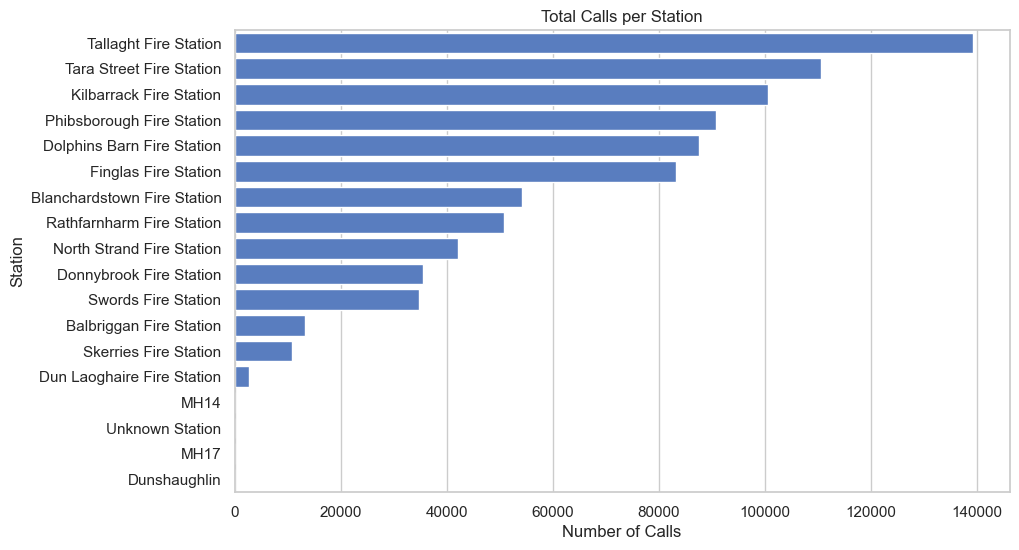

In [13]:
# Ensure plots look nice
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)

station_counts = df['station_id'].value_counts().sort_values(ascending=False)
sns.barplot(x=station_counts.values, y=station_counts.index)
plt.title("Total Calls per Station")
plt.xlabel("Number of Calls")
plt.ylabel("Station")
plt.show()

***Calls per Station***

In [14]:
df

,date,station_id,criticality,toc,ord,mob,ia,ls,ah,mav,cd
0,01/01/2013,Tallaght Fire Station,Non ProQa Class,00:02:09,00:04:14,00:04:58,00:10:16,NaN,NaN,00:27:47,00:29:24
1,01/01/2013,Tara Street Fire Station,B,00:02:41,00:14:41,00:15:04,00:18:10,NaN,NaN,00:20:52,00:22:47
2,01/01/2013,Finglas Fire Station,D,00:13:52,00:16:26,00:16:51,00:25:06,00:29:36,00:37:35,00:41:49,00:47:15
3,01/01/2013,Tara Street Fire Station,B,00:06:58,00:22:33,00:22:59,00:34:48,NaN,NaN,00:43:21,00:44:18
4,01/01/2013,Tara Street Fire Station,A,00:14:56,00:23:25,00:23:35,00:27:25,00:39:19,NaN,01:05:37,01:12:15
...,...,...,...,...,...,...,...,...,...,...,...
856148,31/12/2022,Kilbarrack Fire Station,D,23:36:14,23:39:43,23:41:39,23:45:58,00:12:06,00:17:48,01:18:35,NaN
856149,31/12/2022,Tallaght Fire Station,D,23:39:59,23:44:53,23:46:56,23:52:47,00:30:17,00:38:20,01:27:03,NaN
856150,31/12/2022,Kilbarrack Fire Station,A,23:40:49,02:29:12,02:29:43,NaN,02:55:37,02:57:50,03:49:55,NaN
856151,31/12/2022,Dolphins Barn Fire Station,D,23:49:10,01:48:36,01:49:01,02:04:12,02:24:23,02:34:10,03:09:34,NaN


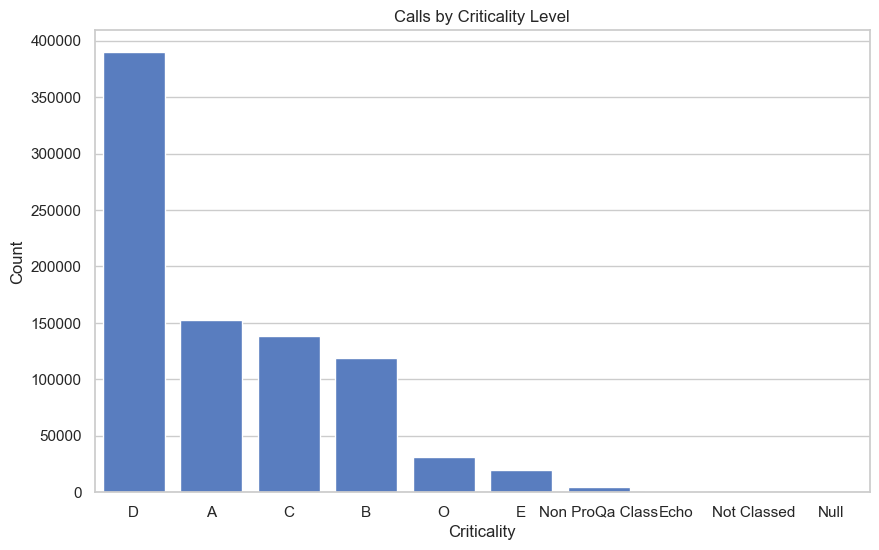

In [15]:
sns.countplot(data=df, x='criticality', order=df['criticality'].value_counts().index)
plt.title("Calls by Criticality Level")
plt.xlabel("Criticality")
plt.ylabel("Count")
plt.show()

The `criticality` codes—typically seen as **Echo, Delta, Charlie, Bravo, Alpha, Omega** in Dublin Fire Brigade / Ambulance datasets—represent increasing levels of **call urgency and required response prioritization**. Here’s what each means according to the **Medical Priority Dispatch System (MPDS)** used by Dublin’s EMS:

* **Echo**: Most urgent — life-threatening (e.g., cardiac or respiratory arrest)
* **Delta**: Life-threatening but not cardiac or respiratory arrest
* **Charlie**: Serious and non–life-threatening situations that still require immediate attention
* **Bravo**: Serious but less urgent, still non–life-threatening
* **Alpha**: Non-serious, non–life-threatening calls
* **Omega**: Lowest priority — minor illness or injury

***Calls per Year***

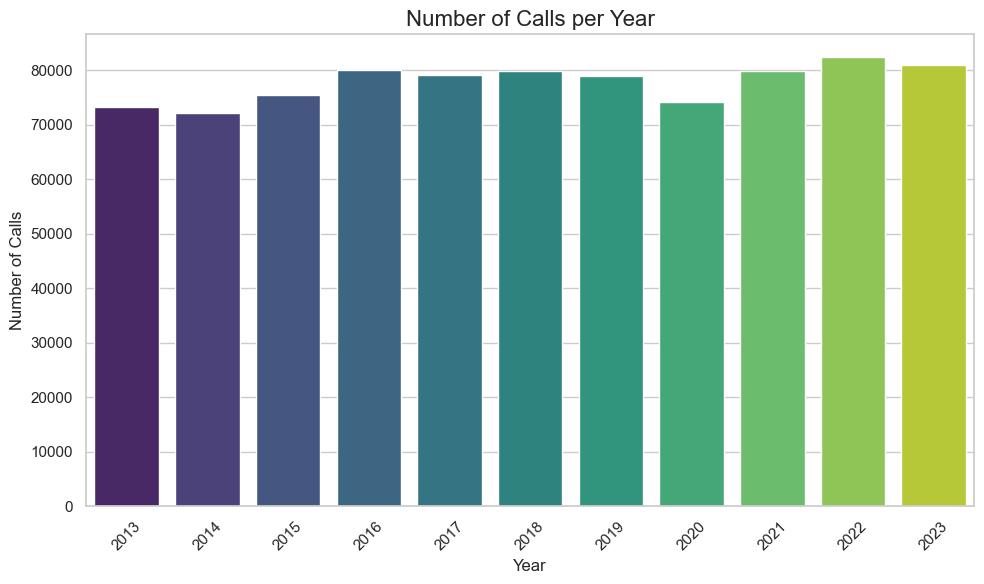

In [16]:
# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Extract year
df['year'] = df['date'].dt.year

# Count calls per year
year_counts = df['year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=year_counts.index, y=year_counts.values, palette="viridis")
plt.title("Number of Calls per Year", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Calls", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


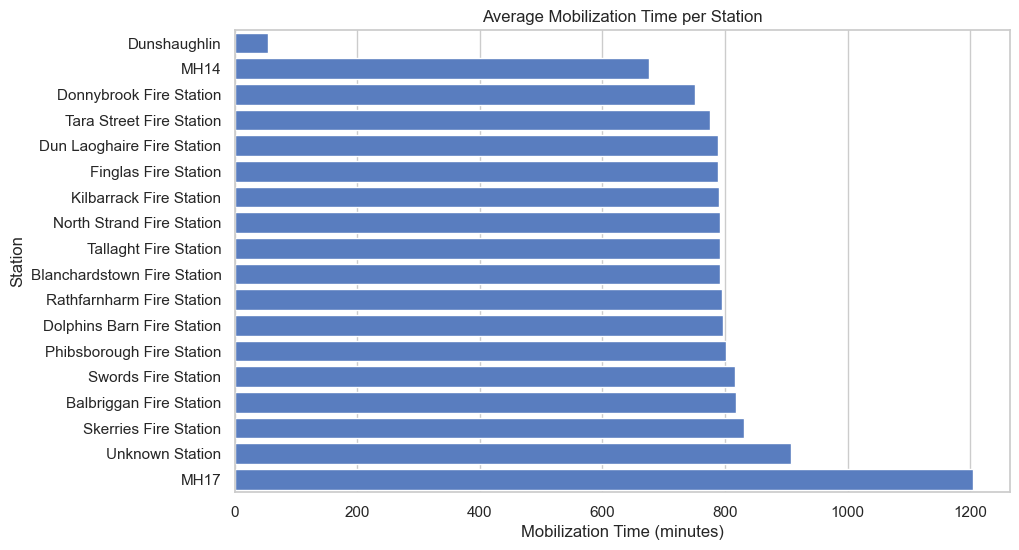

In [17]:
# Average Response Time by Station ---
def time_to_seconds(t):
    try:
        h, m, s = map(int, t.split(":"))
        return h*3600 + m*60 + s
    except:
        return None

df['mob_seconds'] = df['mob'].apply(lambda x: time_to_seconds(str(x)) if pd.notnull(x) else None)
avg_response = df.groupby('station_id')['mob_seconds'].mean().sort_values()
sns.barplot(x=avg_response.values/60, y=avg_response.index)
plt.title("Average Mobilization Time per Station")
plt.xlabel("Mobilization Time (minutes)")
plt.ylabel("Station")
plt.show()

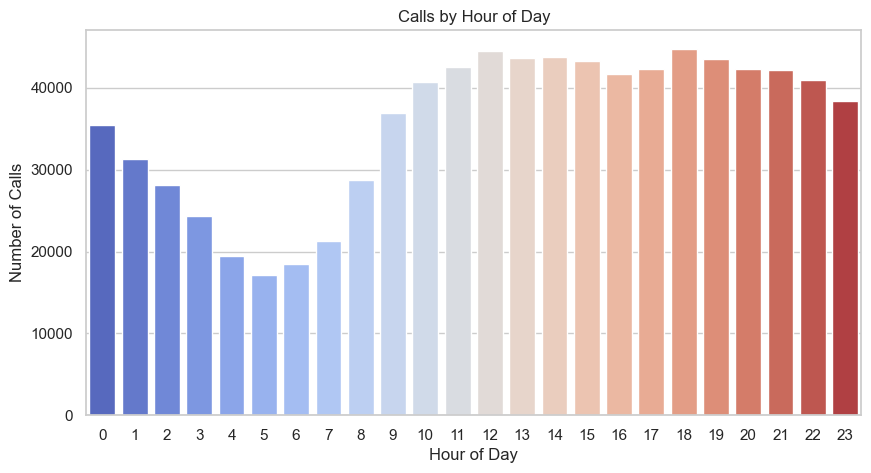

In [18]:
df['hour'] = pd.to_datetime(df['toc'], errors='coerce').dt.hour
calls_by_hour = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=calls_by_hour.index, y=calls_by_hour.values, palette="coolwarm")
plt.title("Calls by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Calls")
plt.show()


***Calls by Day of Week***

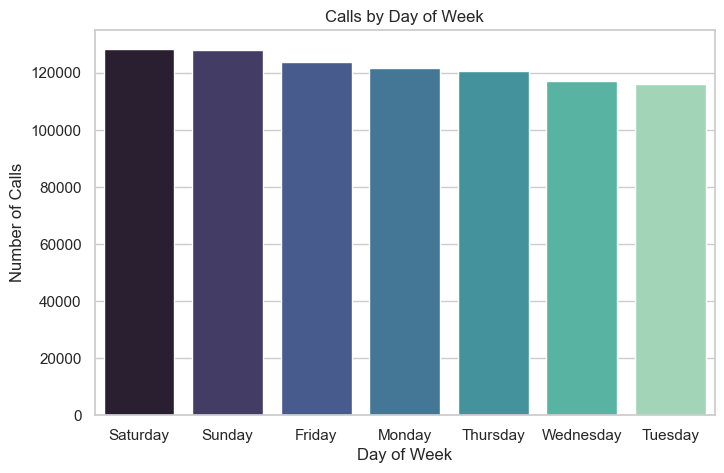

In [19]:
df['day_of_week'] = df['date'].dt.day_name()
calls_by_day = df['day_of_week'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=calls_by_day.index, y=calls_by_day.values, palette="mako")
plt.title("Calls by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Calls")
plt.show()


***Criticality Distribution by Year***

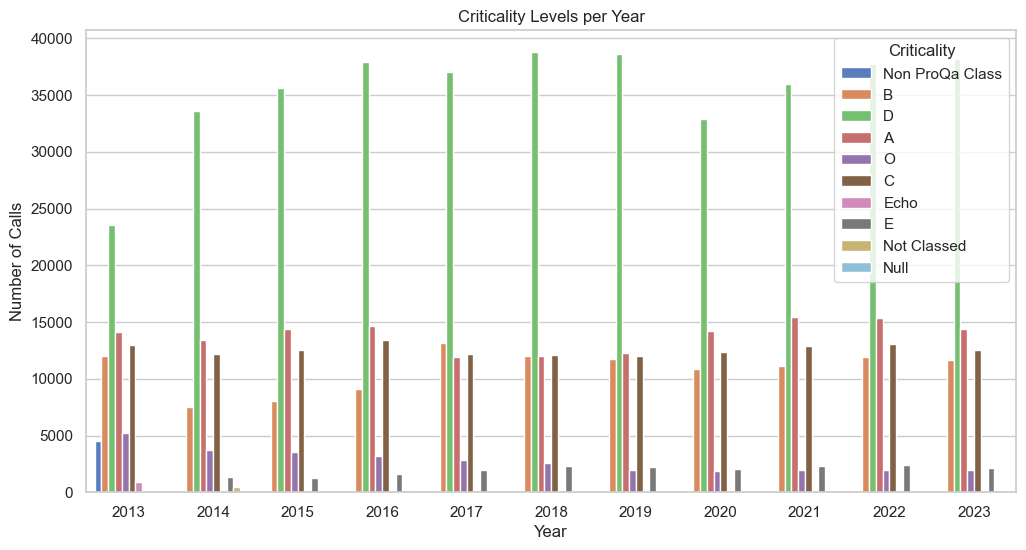

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='year', hue='criticality', order=sorted(df['year'].unique()))
plt.title("Criticality Levels per Year")
plt.xlabel("Year")
plt.ylabel("Number of Calls")
plt.legend(title="Criticality")
plt.show()


<h1 style="color: darkgray;font-family:san=serif;text-align:left;font-weight:bold;font-size:30px">Data Preprocessing</h1>

In [21]:
df.shape

(856153, 15)

In [22]:
df.isnull().sum()

date                0
station_id          0
criticality         0
toc                 0
ord                 0
mob             18264
ia             141694
ls             326935
ah             297965
mav             77868
cd             236638
year                0
mob_seconds     18264
hour                0
day_of_week         0
dtype: int64

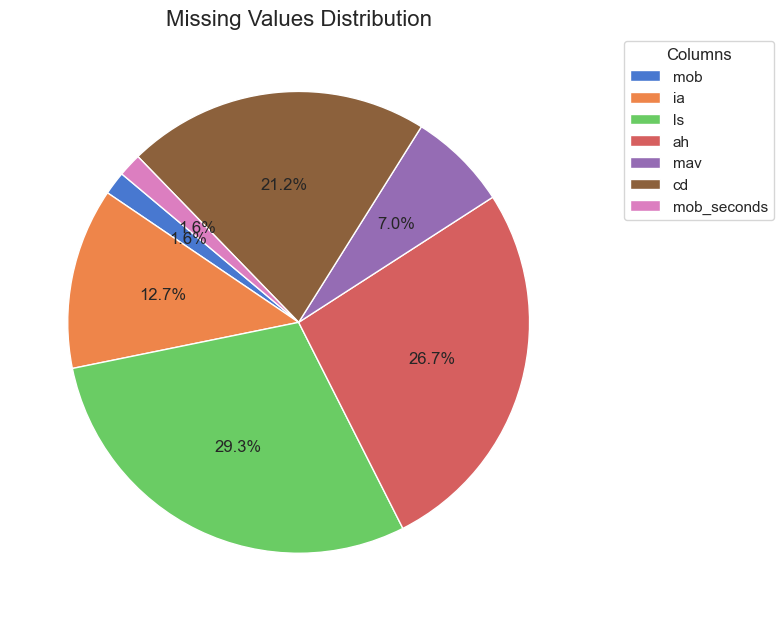

In [23]:
# Get missing values only
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(missing_counts, labels=None, autopct='%1.1f%%', startangle=140)
plt.title("Missing Values Distribution", fontsize=16)

# Legend outside the chart
plt.legend(missing_counts.index, title="Columns", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


We’re not handling most nulls because they’re in columns **not used for prediction**, so they don’t affect the model.
Dropping or filling them unnecessarily could remove useful call records and reduce data accuracy.


****CALCULATE HOURLY CALL COUNTS****

In [24]:
df['timestamp'] = pd.to_datetime(df['date'], errors='coerce')

df = df.dropna(subset=['timestamp', 'station_id'])

#  EXTRACT TEMPORAL FEATURES
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour

# CALCULATE HOURLY CALL COUNTS
hourly_calls = (
    df.groupby(['station_id', 'year', 'month', 'day', 'hour'])
    .size()
    .reset_index(name='hourly_call_count')
)

In [25]:
hourly_calls.head()

,station_id,year,month,day,hour,hourly_call_count
0,Balbriggan Fire Station,2013,1,1,0,4
1,Balbriggan Fire Station,2013,1,2,0,1
2,Balbriggan Fire Station,2013,1,3,0,1
3,Balbriggan Fire Station,2013,1,4,0,4
4,Balbriggan Fire Station,2013,1,5,0,2


In [26]:
hourly_calls['hourly_call_count'].mean()

np.float64(15.992397496964603)

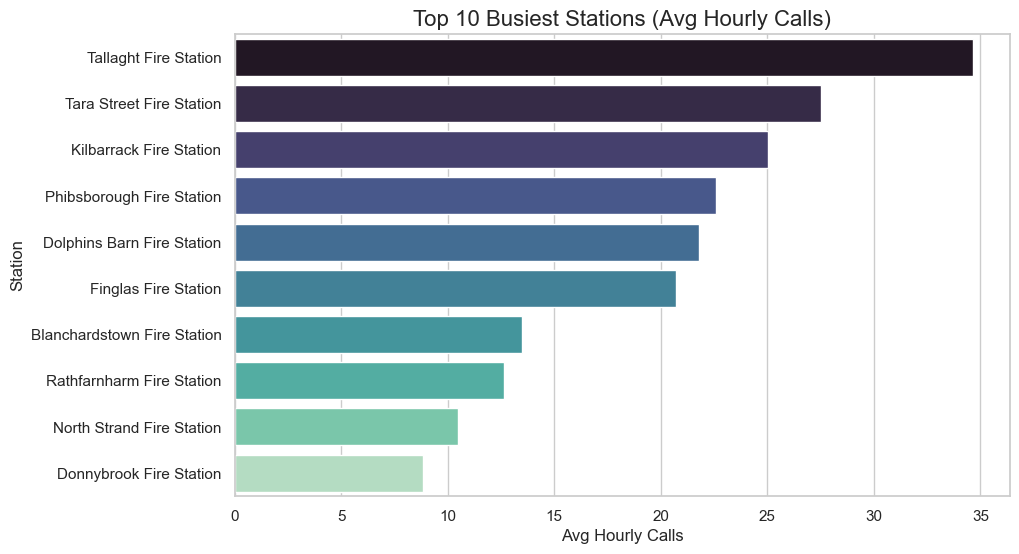

In [27]:
plt.figure(figsize=(10,6))
top_stations = (
    hourly_calls.groupby('station_id')['hourly_call_count']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=top_stations, x='hourly_call_count', y='station_id', palette='mako')
plt.title("Top 10 Busiest Stations (Avg Hourly Calls)", fontsize=16)
plt.xlabel("Avg Hourly Calls", fontsize=12)
plt.ylabel("Station", fontsize=12)
plt.show()

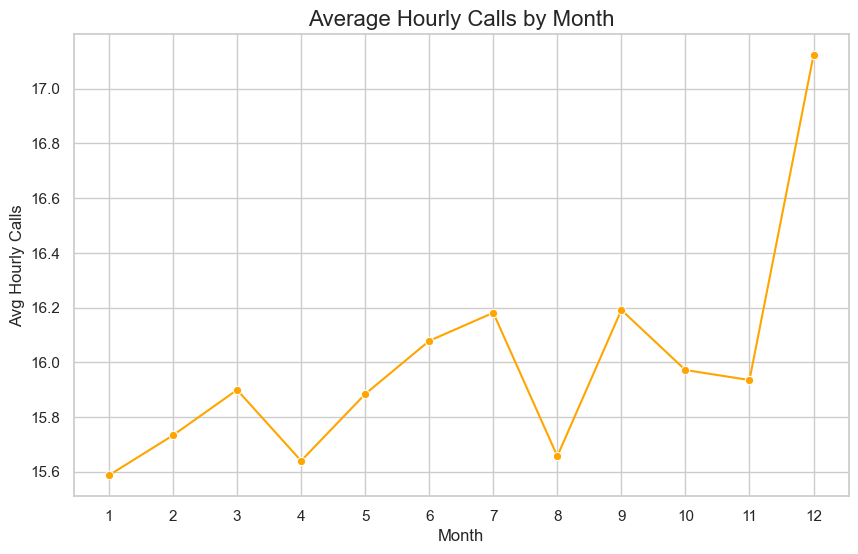

In [28]:
plt.figure(figsize=(10,6))
monthly_avg = hourly_calls.groupby('month')['hourly_call_count'].mean().reset_index()
sns.lineplot(data=monthly_avg, x='month', y='hourly_call_count', marker='o', color='orange')
plt.title("Average Hourly Calls by Month", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Avg Hourly Calls", fontsize=12)
plt.xticks(range(1,13))
plt.show()

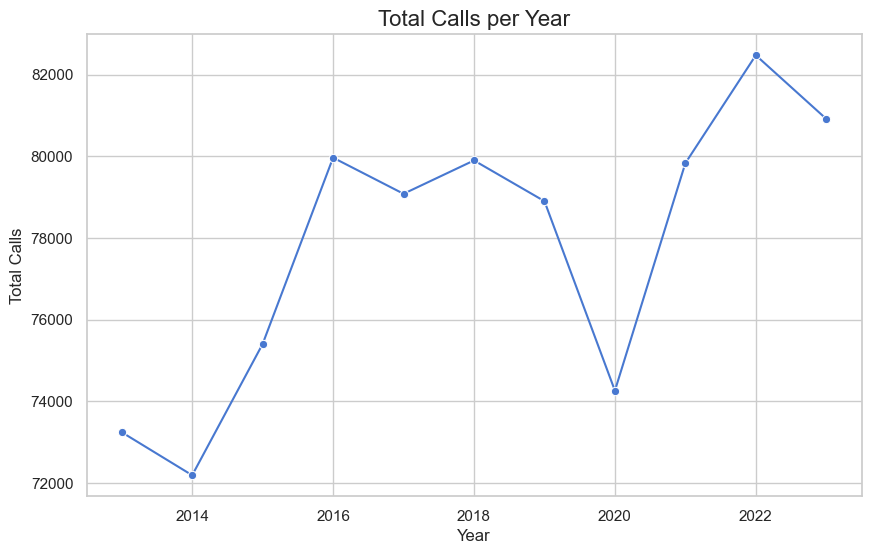

In [29]:
plt.figure(figsize=(10,6))
yearly_total = hourly_calls.groupby('year')['hourly_call_count'].sum().reset_index()
sns.lineplot(data=yearly_total, x='year', y='hourly_call_count', marker='o')
plt.title("Total Calls per Year", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Calls", fontsize=12)
plt.show()

***Feature Engineer***

In [27]:
import holidays
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ie_holidays = holidays.Ireland() #Irish holidays so it can mark calls happening on those days.
        self.station_avgs = None
        
    def fit(self, X, y=None):
        # Calculate station averages for filling missing values
        if y is not None:
            self.station_avgs = pd.Series(y).groupby(X['station_id']).mean()
        return self
        
    def transform(self, X, y=None):
        X = X.copy()
        
        # Create datetime column
        X['datetime'] = pd.to_datetime(X[['year', 'month', 'day', 'hour']])
        
        # Basic temporal features
        X['day_of_week'] = X['datetime'].dt.dayofweek
        X['is_weekend'] = (X['day_of_week'] >= 5).astype(int) #Marks weekends separately
        X['is_holiday'] = X['datetime'].apply(lambda x: x in self.ie_holidays).astype(int) # Marks if the date is a public holiday in Ireland.
         
        # Time of day features
        X['is_night'] = ((X['hour'] >= 0) & (X['hour'] <= 6)).astype(int)
        X['is_morning'] = ((X['hour'] >= 7) & (X['hour'] <= 11)).astype(int)
        X['is_afternoon'] = ((X['hour'] >= 12) & (X['hour'] <= 17)).astype(int)
        X['is_evening'] = ((X['hour'] >= 18) & (X['hour'] <= 23)).astype(int)
        
        # Cyclical encoding
        X['hour_sin'] = np.sin(2 * np.pi * X['hour']/24) #Turns hours and months into sine & cosine values so the model knows time is circular 
        X['hour_cos'] = np.cos(2 * np.pi * X['hour']/24)  # (23:00 is close to 0:00, December is close to January).
        X['month_sin'] = np.sin(2 * np.pi * X['month']/12)
        X['month_cos'] = np.cos(2 * np.pi * X['month']/12)
        
        # Seasonality
        X['season'] = X['month'] % 12 // 3 + 1  # Marks which season (1 to 4) the call is in based on month.
        
        # Drop datetime columns
        X = X.drop(columns=['datetime', 'day_of_week']) #Cleaning and droping
        
        return X

***Copying to df***

In [28]:
df = hourly_calls.copy()

print("Data preview:")
print(df.head())

Data preview:
                station_id  year  month  day  hour  hourly_call_count
0  Balbriggan Fire Station  2013      1    1     0                  4
1  Balbriggan Fire Station  2013      1    2     0                  1
2  Balbriggan Fire Station  2013      1    3     0                  1
3  Balbriggan Fire Station  2013      1    4     0                  4
4  Balbriggan Fire Station  2013      1    5     0                  2


In [29]:
# Separate features & target
X = df.drop(columns=['hourly_call_count'])
y = df['hourly_call_count']

In [30]:
X.head()

,station_id,year,month,day,hour
0,Balbriggan Fire Station,2013,1,1,0
1,Balbriggan Fire Station,2013,1,2,0
2,Balbriggan Fire Station,2013,1,3,0
3,Balbriggan Fire Station,2013,1,4,0
4,Balbriggan Fire Station,2013,1,5,0


In [31]:
y.head()

0    4
1    1
2    1
3    4
4    2
Name: hourly_call_count, dtype: int64

***Apply Feature Engineering***

In [32]:
engineer = FeatureEngineer()

# Apply feature engineering
X_eng = engineer.transform(X)

X_eng.head()

,station_id,year,month,day,hour,is_weekend,is_holiday,is_night,is_morning,is_afternoon,is_evening,hour_sin,hour_cos,month_sin,month_cos,season
0,Balbriggan Fire Station,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.5,0.866025,1
1,Balbriggan Fire Station,2013,1,2,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
2,Balbriggan Fire Station,2013,1,3,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
3,Balbriggan Fire Station,2013,1,4,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
4,Balbriggan Fire Station,2013,1,5,0,1,0,1,0,0,0,0.0,1.0,0.5,0.866025,1


In [33]:
from sklearn.preprocessing import LabelEncoder
import joblib
station_encoder = LabelEncoder()

# Fit on station_id and transform
X_eng['station_id'] = station_encoder.fit_transform(X_eng['station_id'])

# Save the encoder
joblib.dump(station_encoder, 'models/station_id_label_encoder.pkl')

['models/station_id_label_encoder.pkl']

In [34]:
X_eng.head()

,station_id,year,month,day,hour,is_weekend,is_holiday,is_night,is_morning,is_afternoon,is_evening,hour_sin,hour_cos,month_sin,month_cos,season
0,0,2013,1,1,0,0,1,1,0,0,0,0.0,1.0,0.5,0.866025,1
1,0,2013,1,2,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
2,0,2013,1,3,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
3,0,2013,1,4,0,0,0,1,0,0,0,0.0,1.0,0.5,0.866025,1
4,0,2013,1,5,0,1,0,1,0,0,0,0.0,1.0,0.5,0.866025,1


****Split Train/Test****

In [35]:
X_eng = X_eng.sort_values(['year', 'month', 'day', 'hour'])
y = y.loc[X_eng.index]  # keep target aligned

# ML MODELS (80% train, 20% test)
split_idx = int(0.8 * len(X_eng))
X_train, X_test = X_eng.iloc[:split_idx], X_eng.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("ML Split Shapes:")

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Save ML splits
os.makedirs('SplittedData', exist_ok=True)
X_train.to_csv("SplittedData/X_train.csv", index=False)
X_test.to_csv("SplittedData/X_test.csv", index=False)
y_train.to_csv("SplittedData/y_train.csv", index=False)
y_test.to_csv("SplittedData/y_test.csv", index=False)

ML Split Shapes:
(42828, 16) (10707, 16) (42828,) (10707,)


---